# Exploratory analysis — bank marketing campaign

Goal: understand the data well enough to make defensible modelling decisions, before
writing any pipeline code.

Three questions drive this notebook, because each one changes what the pipeline must do:

1. Are any features unavailable at prediction time? (leakage)
2. Is there a time dimension, and does the data drift along it? (splitting strategy)
3. Are any encodings lying to us? (sentinels, collinearity)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score

pd.set_option("display.width", 120)

df = pd.read_csv("../data/dataset.csv", sep=";")
print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## The shape of the problem

Binary classification on tabular data, and the target is imbalanced — so accuracy will be
a useless metric (predicting "no" for everyone already scores ~88%).

In [2]:
target_rate = df["y"].eq("yes").mean()
print(f"rows: {len(df):,}   columns: {df.shape[1]}")
print(f"target rate: {target_rate:.4f}  ({df.y.eq('yes').sum():,} yes / {df.y.eq('no').sum():,} no)")
print(f"accuracy of always predicting 'no': {1 - target_rate:.4f}")
print("\nnulls per column:", df.isna().sum().sum())

rows: 45,211   columns: 17
target rate: 0.1170  (5,289 yes / 39,922 no)
accuracy of always predicting 'no': 0.8830

nulls per column: 0


No literal nulls — but "unknown" is used as a category, which is missingness wearing a
disguise. It matters most in `poutcome`, where it covers 82% of rows.

In [3]:
cat_cols = df.drop(columns="y").select_dtypes(exclude="number").columns
unknown_share = (
    df[cat_cols].eq("unknown").mean().loc[lambda s: s > 0].sort_values(ascending=False)
)
print("share of rows marked 'unknown':")
print(unknown_share.to_string())

share of rows marked 'unknown':
poutcome     0.817478
contact      0.287983
education    0.041074
job          0.006370


## Finding 1 — `duration` is target leakage

`duration` is the length of the call whose outcome we are predicting. It cannot be known
before placing the call, and by the time it *is* known, so is the answer.

The UCI dataset documentation says exactly this:

> this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet,
> the duration is not known before a call is performed. Also, after the end of the call y
> is obviously known. Thus, this input should only be included for benchmark purposes and
> should be discarded if the intention is to have a realistic predictive model.

The evidence below is what that note looks like in the data.

In [4]:
zero_dur = df[df.duration == 0]
print(f"rows with duration == 0: {len(zero_dur)}  -> y='yes' in {zero_dur.y.eq('yes').sum()} of them")

# A single feature should not be able to do this well on its own.
auc_duration_alone = roc_auc_score(df.y.eq("yes"), df.duration)
print(f"\nROC-AUC using duration as the ONLY predictor: {auc_duration_alone:.4f}")

print("\nmedian call duration (seconds):")
print(df.groupby("y")["duration"].median().to_string())

rows with duration == 0: 3  -> y='yes' in 0 of them

ROC-AUC using duration as the ONLY predictor: 0.8076

median call duration (seconds):
y
no     164.0
yes    426.0


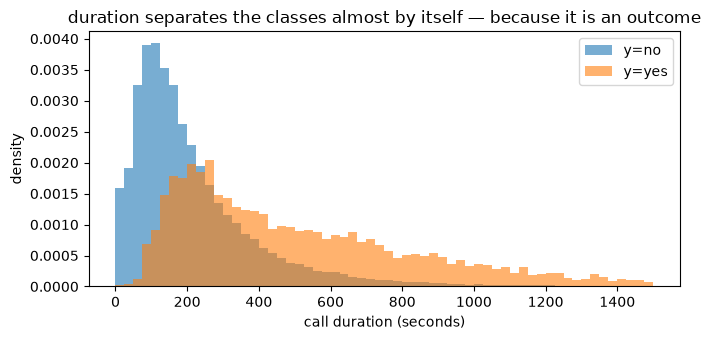

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for label, sub in df.groupby("y"):
    ax.hist(sub.duration, bins=60, range=(0, 1500), alpha=0.6, density=True, label=f"y={label}")
ax.set_xlabel("call duration (seconds)")
ax.set_ylabel("density")
ax.set_title("duration separates the classes almost by itself — because it is an outcome")
ax.legend()
plt.tight_layout()
plt.show()

A single raw feature reaching ~0.81 ROC-AUC unaided, plus "duration=0 implies no", is
decisive. **`duration` is excluded from the model.** It is kept in the codebase behind an
explicit flag so the cost of that decision can be measured rather than assumed.

## Finding 2 — the rows are chronological, and the year is recoverable

There is no year column, only `month`. But the rows are ordered by date, so every time the
month sequence steps *backwards* we have crossed a year boundary. Counting those rollovers
reconstructs the campaign year.

In [6]:
MONTHS = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
month_num = df.month.map({m: i for i, m in enumerate(MONTHS, start=1)})

rollovers = (month_num.diff() < 0)
print(f"backwards steps in the month sequence: {rollovers.sum()}")

year = (2008 + rollovers.cumsum()).rename("year")
print("\nrows per recovered year:")
print(year.value_counts().sort_index().to_string())

print("\nmonth span within each recovered year:")
span = pd.DataFrame({"year": year, "m": month_num}).groupby("year")["m"].agg(["min", "max"])
print(span.assign(first=lambda d: [MONTHS[i - 1] for i in d["min"]],
                  last=lambda d: [MONTHS[i - 1] for i in d["max"]])[["first", "last"]].to_string())

backwards steps in the month sequence: 2

rows per recovered year:
year
2008    27729
2009    14862
2010     2620

month span within each recovered year:
     first last
year           
2008   may  dec
2009   jan  dec
2010   jan  nov


The recovered span is **May 2008 → Nov 2010**, which matches the published description of
this dataset. That agreement is the check on the reconstruction: nothing about the
rollover-counting method forces the first month to be May or the last to be Nov.

Now the reason this matters — the target rate is *not* stable over that period:

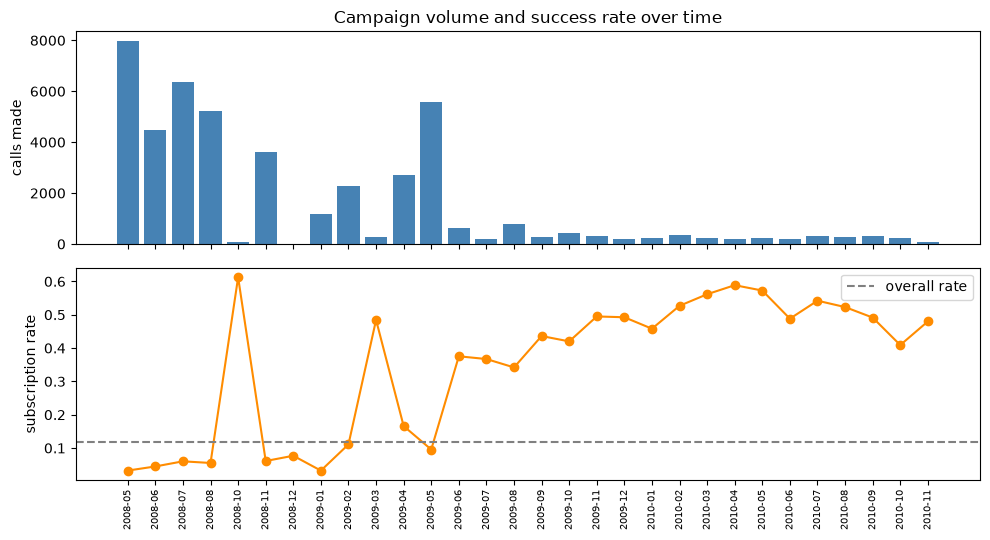

monthly subscription rate ranges 0.032 to 0.613


In [7]:
period = pd.PeriodIndex.from_fields(year=year, month=month_num, freq="M")
by_month = df.assign(period=period).groupby("period").agg(
    calls=("y", "size"), subscribed=("y", lambda s: s.eq("yes").mean())
)

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
axes[0].bar(by_month.index.astype(str), by_month.calls, color="steelblue")
axes[0].set_ylabel("calls made")
axes[0].set_title("Campaign volume and success rate over time")
axes[1].plot(by_month.index.astype(str), by_month.subscribed, marker="o", color="darkorange")
axes[1].axhline(df.y.eq("yes").mean(), ls="--", c="grey", label="overall rate")
axes[1].set_ylabel("subscription rate")
axes[1].legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"monthly subscription rate ranges {by_month.subscribed.min():.3f} to {by_month.subscribed.max():.3f}")

The success rate swings by an order of magnitude across the campaign, and volume is
wildly uneven. This period is 2008–2010 — the financial crisis — so the drift is real
rather than noise.

Two consequences:

- **A random train/test split leaks the future into the past** and will report an
  optimistic score. The evaluation must include an out-of-time split.
- Any model trained here is conditioned on crisis-era behaviour, which limits how far its
  coefficients can be extrapolated. That is a Part B point, not something a better model
  fixes.

## Finding 3 — `pdays = -1` is a sentinel, and it is double-counted

`pdays` is "days since last contact from a previous campaign", with **-1 meaning never
contacted**. Left as a number, -1 sits below 0 on a scale where low values mean "contacted
recently" — the opposite of the truth.

In [8]:
never = df.pdays.eq(-1)
print(f"pdays == -1: {never.sum():,} rows ({never.mean():.1%})")
print(f"\npdays when actually contacted before: min={df.loc[~never, 'pdays'].min()}, "
      f"median={df.loc[~never, 'pdays'].median():.0f}, max={df.loc[~never, 'pdays'].max()}")

print("\ncross-tab of the sentinel against poutcome:")
print(pd.crosstab(never.map({True: "pdays == -1", False: "pdays >= 0"}), df.poutcome).to_string())

pdays == -1: 36,954 rows (81.7%)

pdays when actually contacted before: min=1, median=194, max=871

cross-tab of the sentinel against poutcome:
poutcome     failure  other  success  unknown
pdays                                        
pdays == -1        0      0        0    36954
pdays >= 0      4901   1840     1511        5


`pdays == -1` and `poutcome == "unknown"` describe the same 36,954 customers, differing on
only 5 rows. One-hot encoding both hands the model the same fact twice, which destabilises
linear coefficients and makes any "feature importance" story misleading.

**Decision:** encode as a `contacted_before` flag plus a conditional value, and note the
redundancy rather than encoding it twice.

## Everything else, briefly

A quick pass over the remaining features for anything that would break a naive pipeline.

In [9]:
print(df[["age", "balance", "day", "campaign", "pdays", "previous"]].describe().T.to_string())
print(f"\nnegative balances: {df.balance.lt(0).sum():,} rows (min {df.balance.min():,})")
print(f"campaign contacts — 99th pct {df.campaign.quantile(0.99):.0f}, max {df.campaign.max()}")
print(f"previous contacts — 99th pct {df.previous.quantile(0.99):.0f}, max {df.previous.max()}")
print("\ncategorical cardinality:")
print(df[cat_cols].nunique().sort_values(ascending=False).to_string())

            count         mean          std     min   25%    50%     75%       max
age       45211.0    40.936210    10.618762    18.0  33.0   39.0    48.0      95.0
balance   45211.0  1362.272058  3044.765829 -8019.0  72.0  448.0  1428.0  102127.0
day       45211.0    15.806419     8.322476     1.0   8.0   16.0    21.0      31.0
campaign  45211.0     2.763841     3.098021     1.0   1.0    2.0     3.0      63.0
pdays     45211.0    40.197828   100.128746    -1.0  -1.0   -1.0    -1.0     871.0
previous  45211.0     0.580323     2.303441     0.0   0.0    0.0     0.0     275.0

negative balances: 3,766 rows (min -8,019)
campaign contacts — 99th pct 16, max 63
previous contacts — 99th pct 9, max 275

categorical cardinality:
job          12
month        12
education     4
poutcome      4
marital       3
contact       3
default       2
housing       2
loan          2


In [10]:
rate_by = lambda col: (
    df.groupby(col)["y"].agg(n="size", rate=lambda s: s.eq("yes").mean()).sort_values("rate", ascending=False)
)
print("subscription rate by previous-campaign outcome:")
print(rate_by("poutcome").to_string())
print("\nsubscription rate by contact method:")
print(rate_by("contact").to_string())

subscription rate by previous-campaign outcome:
              n      rate
poutcome                 
success    1511  0.647253
other      1840  0.166848
failure    4901  0.126097
unknown   36959  0.091615

subscription rate by contact method:
               n      rate
contact                   
cellular   29285  0.149189
telephone   2906  0.134205
unknown    13020  0.040707


`poutcome == "success"` converts at ~65% versus ~9% overall — prior success is by far the
strongest honest signal available. `contact == "unknown"` converts at a third of the rate
of a known channel, which likely encodes *how* the record was collected rather than
anything about the customer; worth flagging as a possible artefact.

Heavy right tails in `campaign` (max 63) and `previous` (max 275) argue for tree-based
models, which are indifferent to monotone outliers, alongside a scaled linear baseline.

## What this means for the pipeline

| Finding | Consequence |
| --- | --- |
| `duration` is leakage | Drop it; keep a flag to quantify the cost |
| Data spans May 2008 – Nov 2010, rate drifts | Recover the year; evaluate out-of-time, report random split for contrast |
| `pdays = -1` is a sentinel, collinear with `poutcome` | Flag + conditional value, not a raw number |
| 11.7% positives | PR-AUC, lift and precision@k — never accuracy |
| Long tails, mixed types | Linear baseline + gradient boosting |